In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

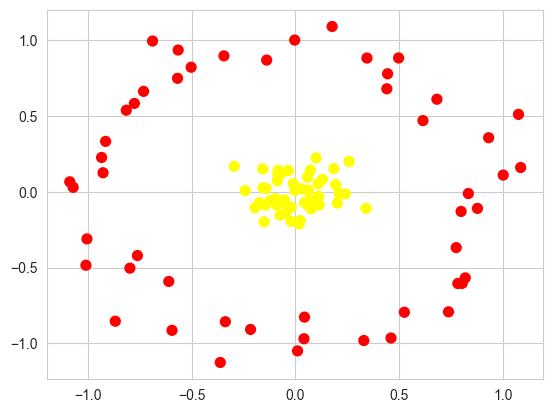

In [2]:
from sklearn.datasets import make_circles

X,y = make_circles(n_samples=100, factor=0.1, noise=.1)
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

[Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

---

## 🧠 Support Vector Classifier (SVC) Parameters

```python
sklearn.svm.SVC(
    C=1.0, kernel='rbf', degree=3, gamma='scale',
    coef0=0.0, shrinking=True, probability=False,
    tol=0.001, cache_size=200, class_weight=None,
    verbose=False, max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False, random_state=None
)
```

---

### **C** `float` *(default = 1.0)*

Regularization parameter:

* Controls trade-off between **margin width** and **classification error**
* **Small C** → More regularization (simpler model)
* **Large C** → Less regularization (fit training data closely)

---

### **kernel** `{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}` *(default = “rbf”)*

Specifies the kernel type:

* **linear** → Linear decision boundary
* **poly** → Polynomial kernel
* **rbf** → Radial Basis Function (most common)
* **sigmoid** → Sigmoid kernel
* **precomputed** → Custom kernel matrix

---

### **degree** `int` *(default = 3)*

Degree of polynomial kernel:

* Used only when `kernel="poly"`

---

### **gamma** `{‘scale’, ‘auto’} or float` *(default = “scale”)*

Kernel coefficient for `rbf`, `poly`, `sigmoid`:

* **scale** → `1 / (n_features * X.var())`
* **auto** → `1 / n_features`
* **float** → Custom value

---

### **coef0** `float` *(default = 0.0)*

Independent term in kernel function:

* Used in **poly** and **sigmoid** kernels

---

### **shrinking** `bool` *(default = True)*

Whether to use shrinking heuristic:

* Speeds up training in some cases

---

### **probability** `bool` *(default = False)*

Enable probability estimates:

* Required for `predict_proba()`
* Slows training (uses internal cross-validation)

---

### **tol** `float` *(default = 1e-3)*

Tolerance for stopping criterion:

* Smaller value → More precise but slower

---

### **cache_size** `float` *(default = 200 MB)*

Kernel cache size:

* Larger → Faster training (uses more memory)

---

### **class_weight** `dict or “balanced”` *(default = None)*

Handles class imbalance:

* **None** → Equal weights
* **dict** → Custom class weights
* **balanced** → Automatically adjusts:

  ```
  n_samples / (n_classes * np.bincount(y))
  ```

---

### **verbose** `bool` *(default = False)*

Enables detailed logging during training

---

### **max_iter** `int` *(default = -1)*

Maximum number of iterations:

* `-1` → No limit

---

### **decision_function_shape** `{‘ovo’, ‘ovr’}` *(default = “ovr”)*

Strategy for multi-class classification:

* **ovr** → One-vs-Rest
* **ovo** → One-vs-One

> Internally, SVC always uses **OvO**, but this controls output format

---

### **break_ties** `bool` *(default = False)*

Break ties using confidence scores:

* Works only when:

  * `decision_function_shape="ovr"`
  * Multi-class classification
* Adds computational cost

---

### **random_state** `int or RandomState` *(default = None)*

Controls randomness:

* Used for probability estimation
* Ensures reproducibility when set

---


In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test, y_pred)

0.45

In [5]:
from matplotlib.colors import ListedColormap
zero_one_colourmap = ListedColormap(['brown', 'white'])

def plot_decision_boundary(X,y, clf):
    x_set, y_set = X, y
    X1, X2 = np.meshgrid(
        np.arange(x_set[:,0].min()-1, x_set[:,0].max()+1, step=0.01),
        np.arange(x_set[:,1].min()-1, x_set[:,1].max()+1, step=0.01)
    )
    
    plt.contourf(X1,
        X2, 
        clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.75,
        cmap=zero_one_colourmap
    )  
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\Jehan\AppData\Local\Temp\ipykernel_13696\124113752.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c = (zero_one_colourmap)(i), label = j)


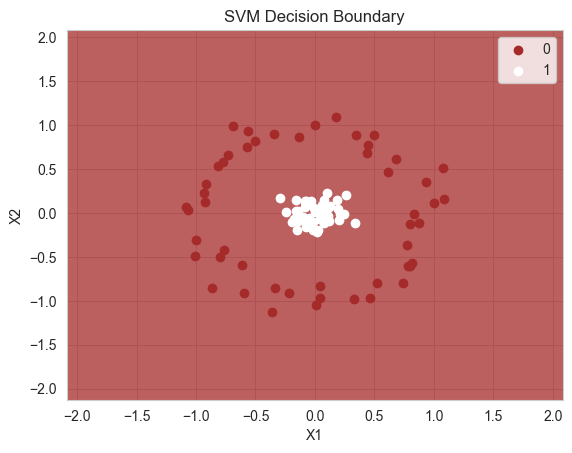

In [6]:
plot_decision_boundary(X,y,svc)

# rbf kernel

1.0


C:\Users\Jehan\AppData\Local\Temp\ipykernel_13696\124113752.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c = (zero_one_colourmap)(i), label = j)


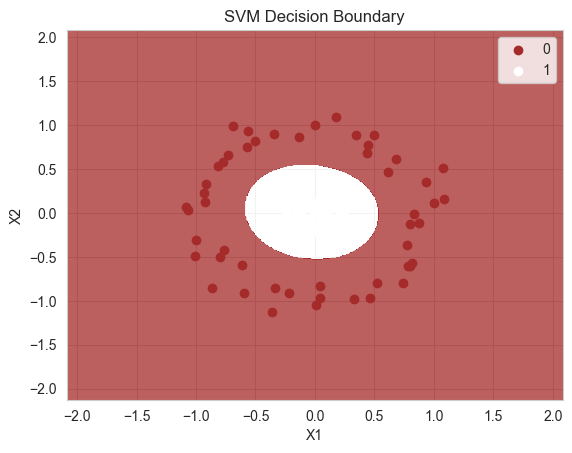

In [7]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(X_train,y_train)
y_pred_rbf = svc_rbf.predict(X_test)
print(accuracy_score(y_test, y_pred_rbf))
plot_decision_boundary(X, y, svc_rbf)

# poly kernel

1.0


C:\Users\Jehan\AppData\Local\Temp\ipykernel_13696\124113752.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c = (zero_one_colourmap)(i), label = j)


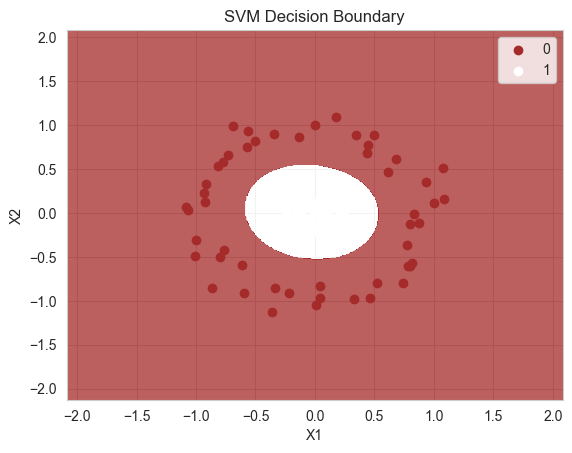

In [8]:
svc_poly = SVC(kernel='poly', degree=2)
svc_poly.fit(X_train,y_train)
y_pred_poly = svc_poly.predict(X_test)
print(accuracy_score(y_test, y_pred_poly))
plot_decision_boundary(X, y, svc_rbf)